# NN5
## 0. setup

In [1]:
from IPython.display import display
from nn5_runtime import *

## 1. dane

In [2]:
display(preview_dataset('multimodal-large', 'regression'))
display(preview_dataset('steps-large', 'regression'))
display(preview_dataset('rings3-regular', 'classification'))
display(preview_dataset('rings5-regular', 'classification'))

,x_train,y_train
0,-0.685726,-74.197483
1,-0.879898,-30.504177
2,1.411932,10.754122
3,1.688954,100.248297
4,-0.573238,-73.832310


,x_train,y_train
0,-1.481354,-80.0
1,1.033264,80.0
2,-0.076403,0.0
3,-1.419785,-80.0
4,-0.108398,0.0


,x,y,c
0,-93.563317,-76.345110,0
1,1.060114,-16.727040,0
2,24.396099,40.358822,0
3,-94.595137,-97.889250,0
4,-85.331382,-56.736933,0


,x,y,c
0,26.926121,-16.588451,0
1,-77.438767,95.159464,0
2,-98.650099,94.923714,0
3,22.241184,-5.447678,0
4,12.843637,-21.496457,0


## 1a. interpretacja
Regresja przewiduje wartosc liczbowa, wiec na wyjsciu jest linear i patrzymy glownie na MSE.

Klasyfikacja przewiduje klase, wiec na wyjsciu jest softmax i patrzymy glownie na macro F1.

Ranking pokazuje wynik koncowy, krzywe uczenia pokazuja zbieznosc, residuals pokazuja bledy w regresji, a confusion matrix i mapa decyzji pokazuja zachowanie klasyfikatora.

## 2. multimodal-large

In [3]:
multimodal_architectures = [[8], [16], [32], [16, 8], [32, 16], [64, 32], [16, 8, 4], [32, 16, 8], [64, 32, 16]]
multimodal_lr = {'sigmoid': 0.0018, 'linear': 0.0009, 'tanh': 0.0025, 'relu': 0.0018}
multimodal_candidates = []
for hidden_dims in multimodal_architectures:
    for activation in ACTIVATION_ORDER:
        multimodal_candidates.append({
            'hidden_dims': hidden_dims,
            'hidden_activation': activation,
            'epochs': 1800,
            'batch_size': 64,
            'optimizer_name': 'rmsprop',
            'lr': multimodal_lr[activation],
            'decay': 0.92,
            'momentum': 0.9,
            'clip_value': 5.0,
            'eval_every': 40,
        })
len(multimodal_candidates)

36

In [4]:
multimodal_results = run_experiments('multimodal-large', 'regression', multimodal_candidates)
multimodal_table = results_frame(multimodal_results)
display(multimodal_table)

multimodal_finalists = pick_multimodal_finalists(multimodal_table, top_k=2, rel_tol=0.05)
display(multimodal_finalists)

,dataset,task,hidden_dims,hidden_label,depth,activation,optimizer,lr,epochs,batch_size,params,seconds,best_epoch,best_mse,best_scaled_loss
0,multimodal-large,regression,"(64, 32, 16)",64-32-16,3,sigmoid,rmsprop,0.0018,1800,64,2753,125.587134,1800,0.726187,0.000140
1,multimodal-large,regression,"(64, 32, 16)",64-32-16,3,relu,rmsprop,0.0018,1800,64,2753,130.371780,760,1.128144,0.000218
2,multimodal-large,regression,"(64, 32)",64-32,2,relu,rmsprop,0.0018,1800,64,2241,88.045596,1160,1.143139,0.000221
3,multimodal-large,regression,"(32, 16, 8)",32-16-8,3,tanh,rmsprop,0.0025,1800,64,737,98.690041,720,1.381963,0.000267
4,multimodal-large,regression,"(64, 32, 16)",64-32-16,3,tanh,rmsprop,0.0025,1800,64,2753,243.686813,1560,1.756449,0.000339
5,multimodal-large,regression,"(64, 32)",64-32,2,sigmoid,rmsprop,0.0018,1800,64,2241,80.838732,1000,1.826713,0.000353
6,multimodal-large,regression,"(32, 16)",32-16,2,tanh,rmsprop,0.0025,1800,64,609,130.511852,160,1.829457,0.000353
7,multimodal-large,regression,"(16, 8, 4)",16-8-4,3,tanh,rmsprop,0.0025,1800,64,209,65.381796,1800,1.995146,0.000385
8,multimodal-large,regression,"(64, 32)",64-32,2,tanh,rmsprop,0.0025,1800,64,2241,65.781661,1800,2.366458,0.000457
9,multimodal-large,regression,"(32, 16, 8)",32-16-8,3,relu,rmsprop,0.0018,1800,64,737,82.492296,680,2.419711,0.000467


,dataset,task,hidden_dims,hidden_label,depth,activation,optimizer,lr,epochs,batch_size,params,seconds,best_epoch,best_mse,best_scaled_loss
0,multimodal-large,regression,"(64, 32, 16)",64-32-16,3,sigmoid,rmsprop,0.0018,1800,64,2753,125.587134,1800,0.726187,0.000140
1,multimodal-large,regression,"(64, 32, 16)",64-32-16,3,relu,rmsprop,0.0018,1800,64,2753,130.371780,760,1.128144,0.000218


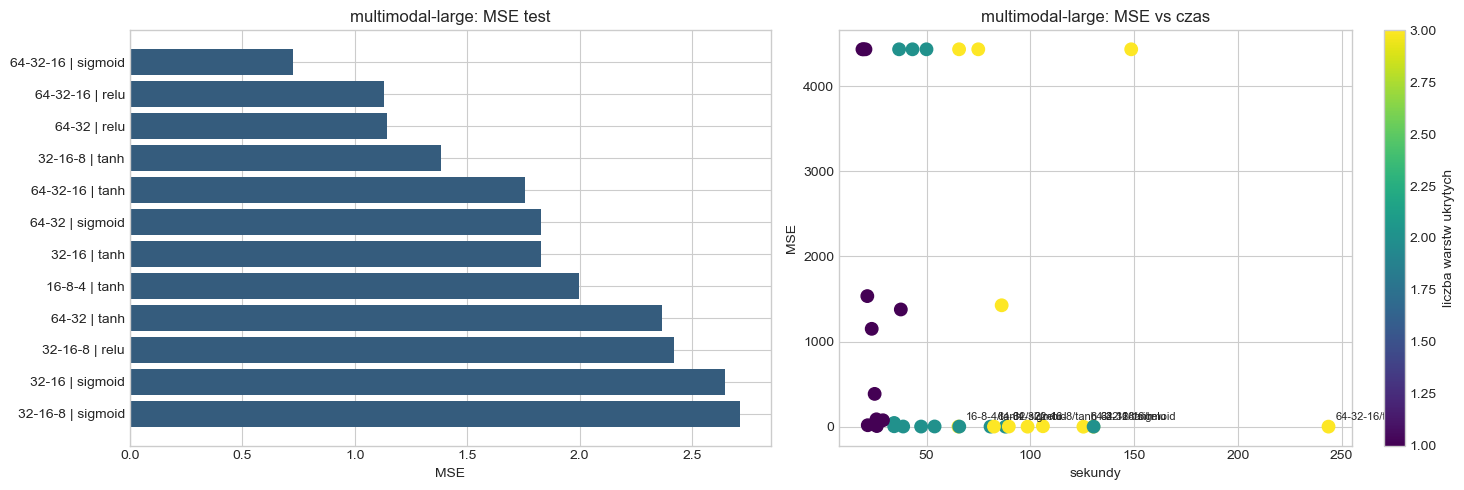

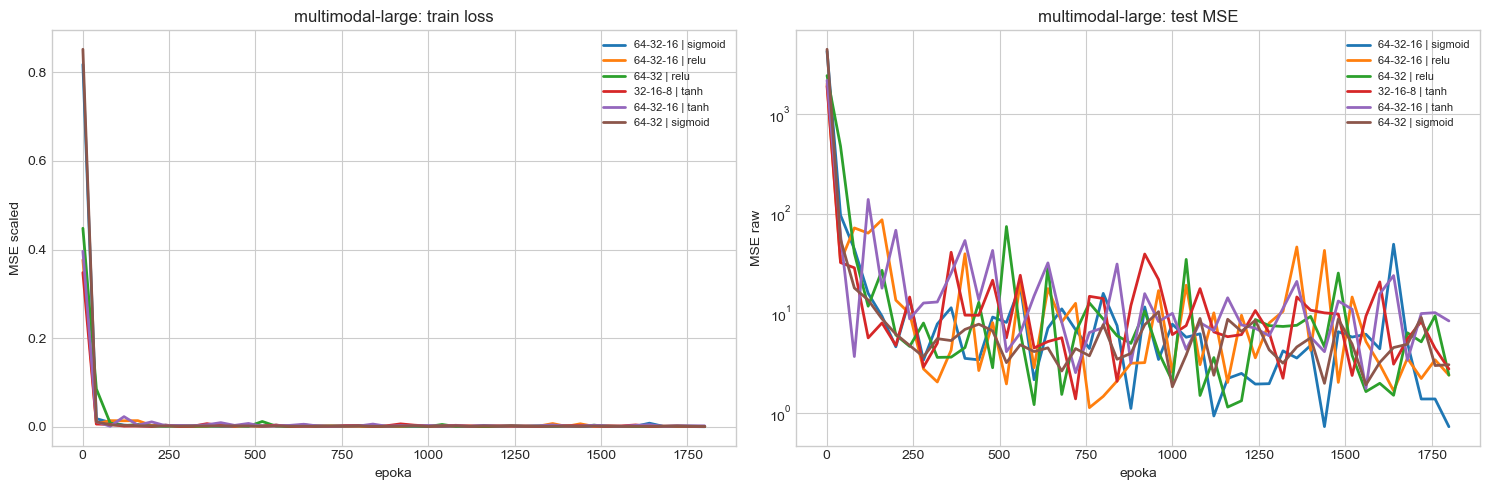

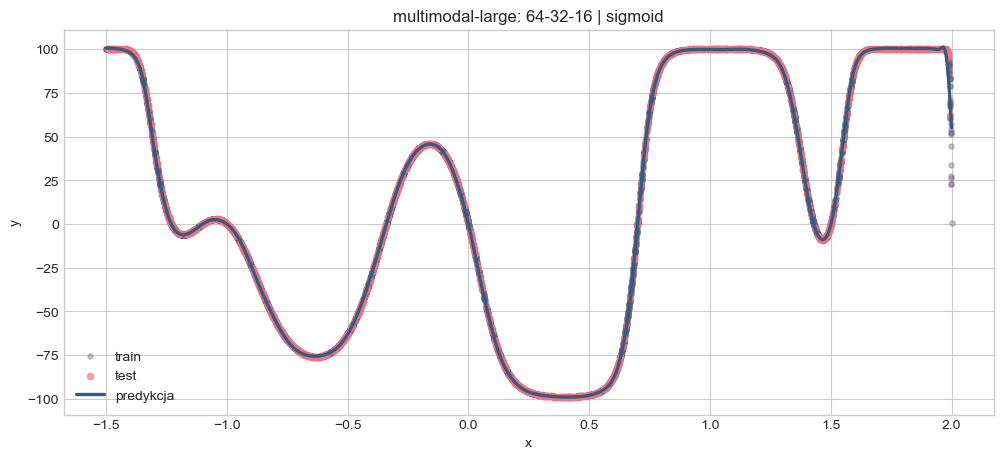

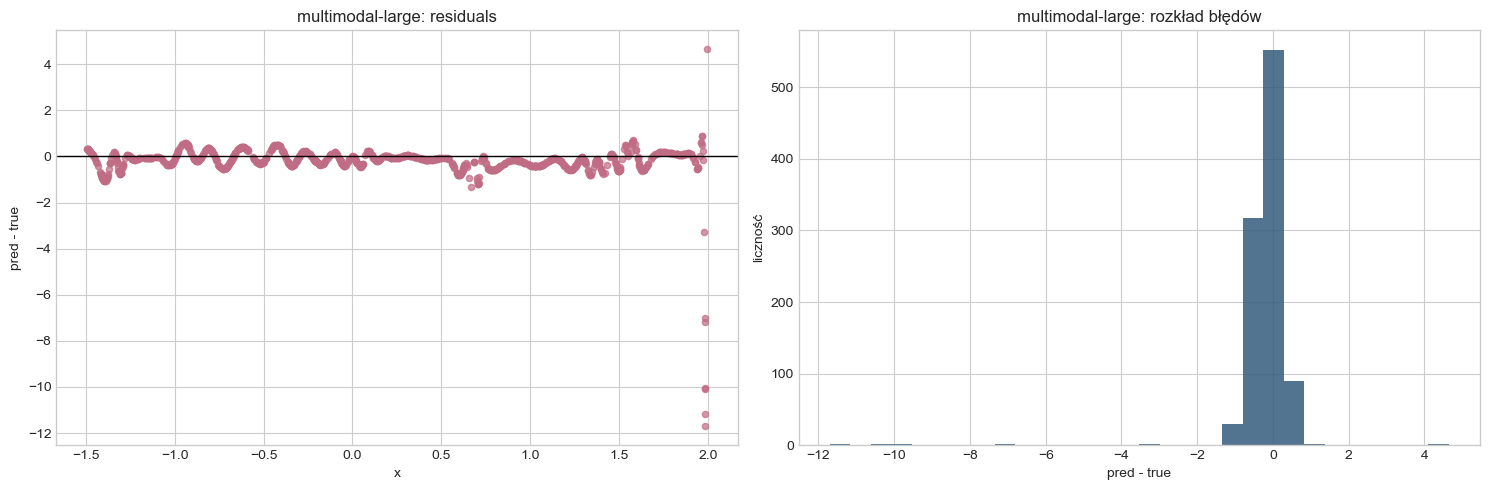

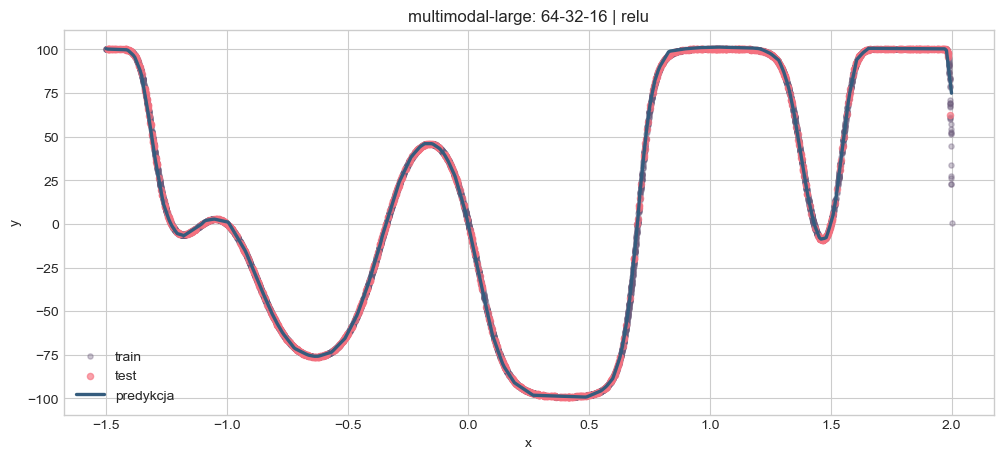

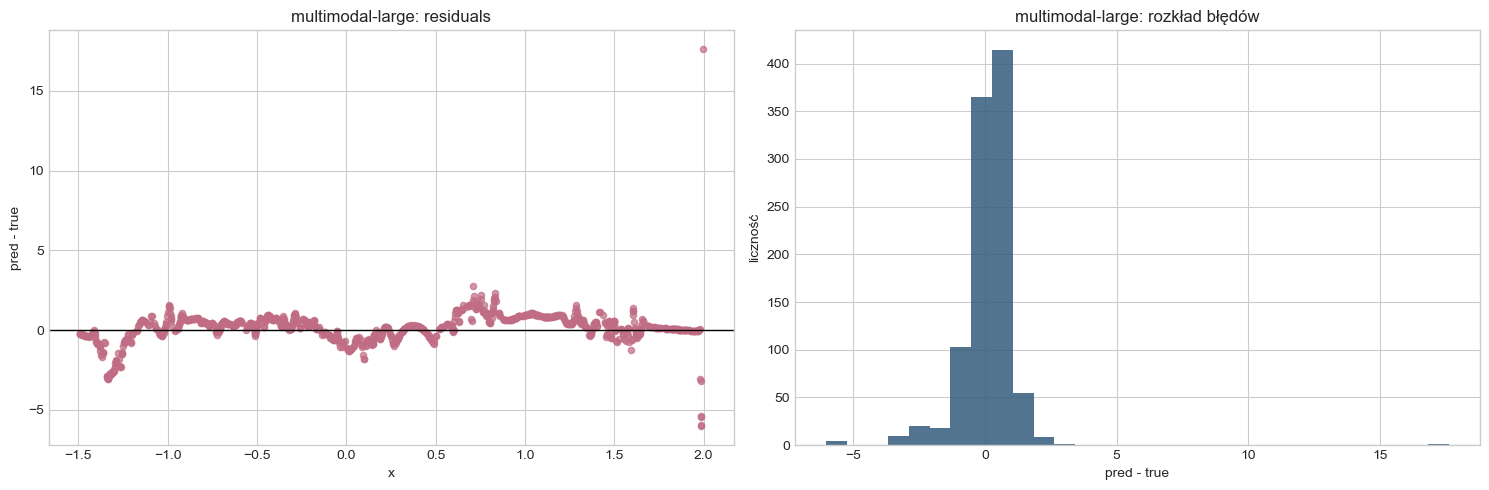

In [5]:
plot_regression_rankings(multimodal_table, 'multimodal-large')
plot_regression_learning(multimodal_results, 'multimodal-large', top_n=6)

for row in multimodal_finalists.itertuples():
    run = find_run(multimodal_results, row.hidden_dims, row.activation)
    plot_regression_fit(run, 'multimodal-large')
    plot_regression_residuals(run, 'multimodal-large')

## 2a. komentarz
Najlepszy wynik na multimodal-large dala architektura 64-32-16 z sigmoid: MSE = 0.726.

Drugie miejsce zajela ta sama architektura z ReLU: MSE = 1.128.

To pokazuje, ze dla tego zbioru najlepiej dziala glebsza siec, a linear w warstwach ukrytych wyraznie przegrywa.

## 3. steps-large

In [6]:
steps_candidates = finalists_to_configs(multimodal_finalists, task='regression')
steps_results = run_experiments('steps-large', 'regression', steps_candidates)
steps_table = results_frame(steps_results)
display(steps_table)

,dataset,task,hidden_dims,hidden_label,depth,activation,optimizer,lr,epochs,batch_size,params,seconds,best_epoch,best_mse,best_scaled_loss
0,steps-large,regression,"(64, 32, 16)",64-32-16,3,relu,rmsprop,0.0018,1800,64,2753,150.510977,1400,0.982702,0.000144
1,steps-large,regression,"(64, 32, 16)",64-32-16,3,sigmoid,rmsprop,0.0018,1800,64,2753,195.712385,1800,3.180699,0.000466


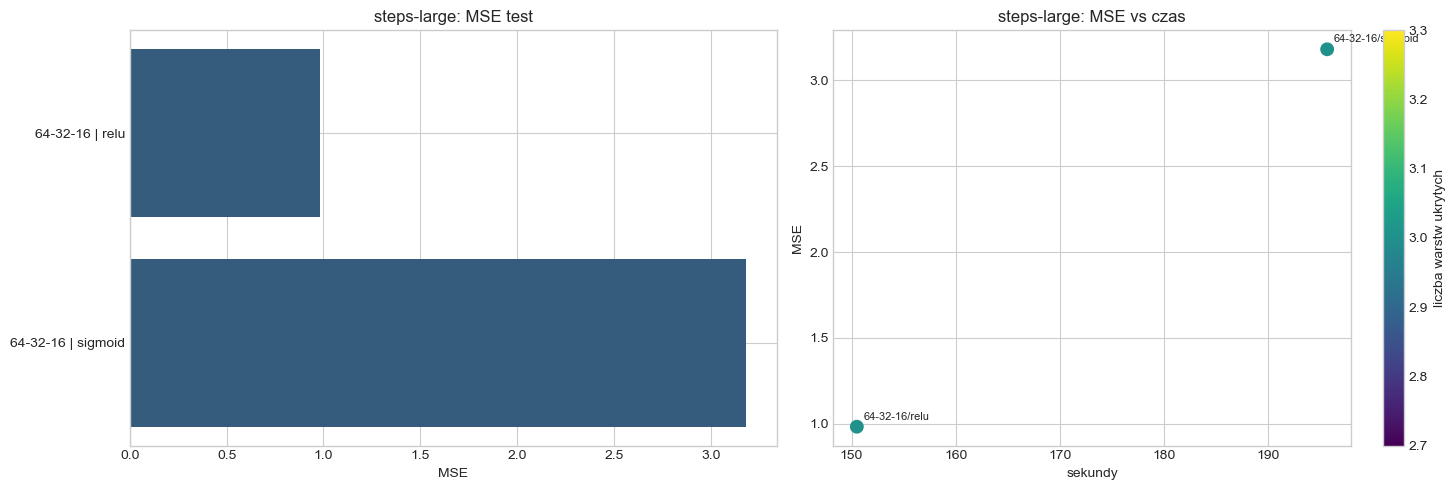

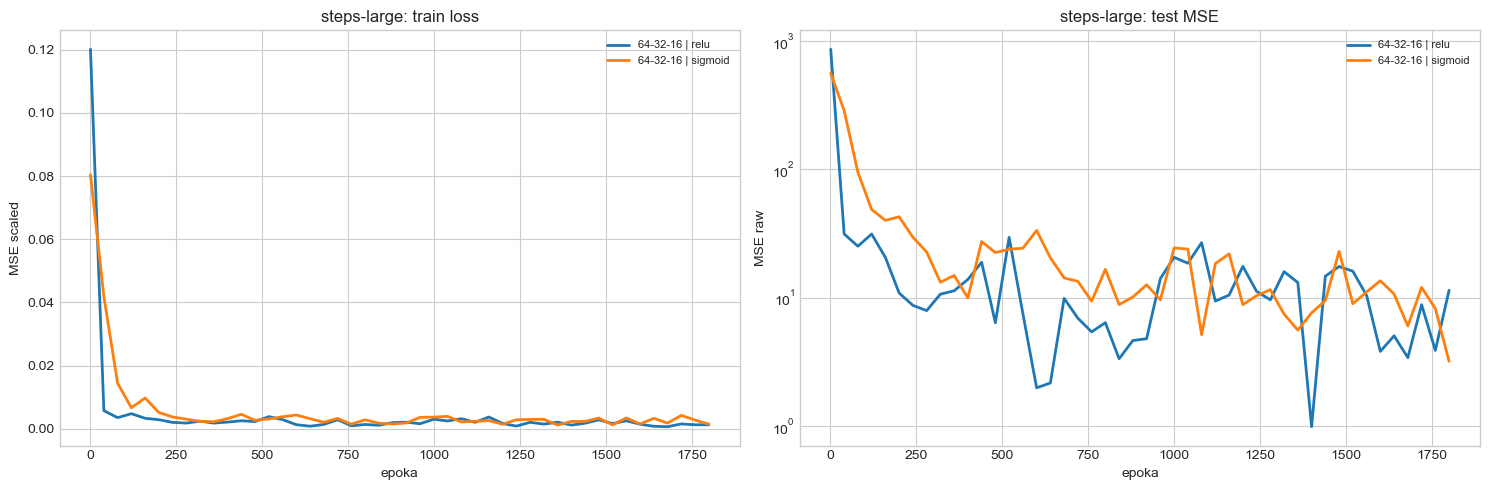

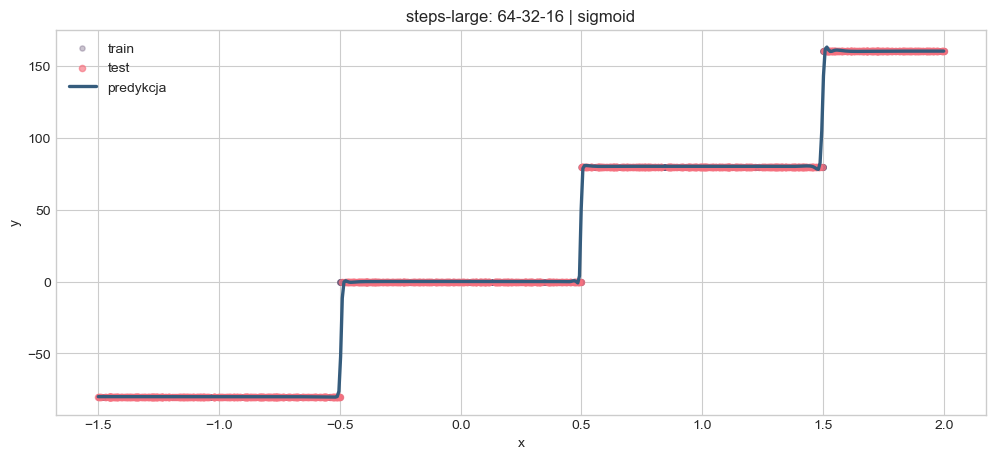

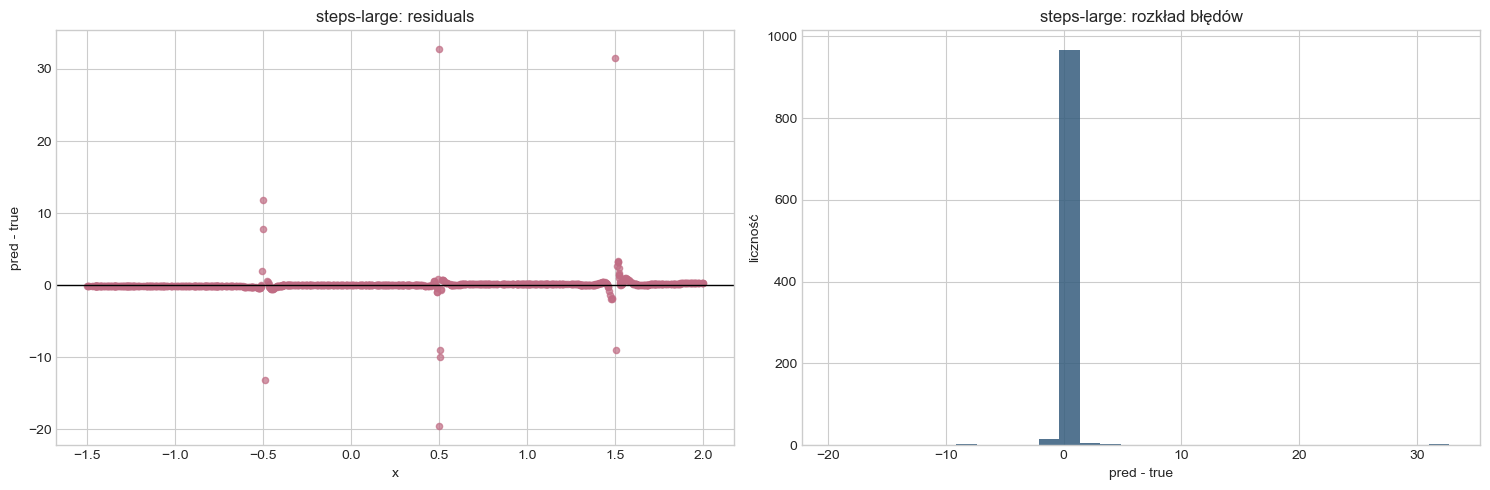

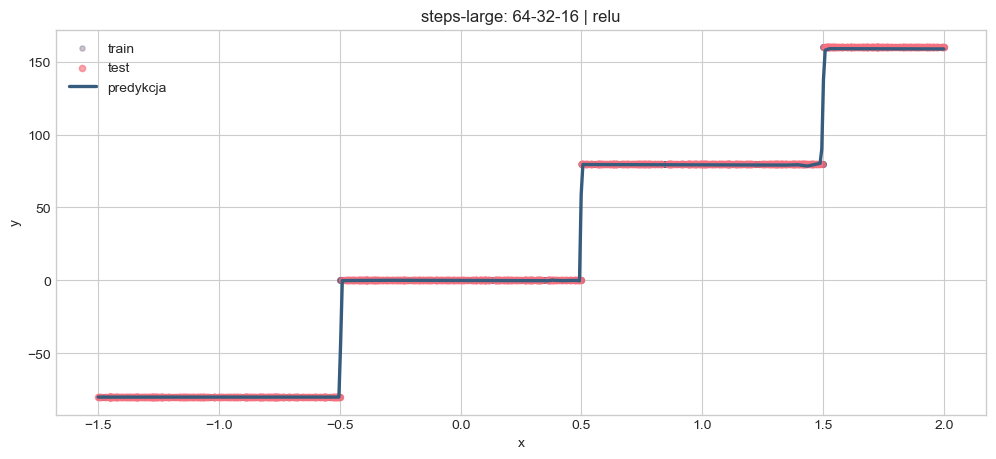

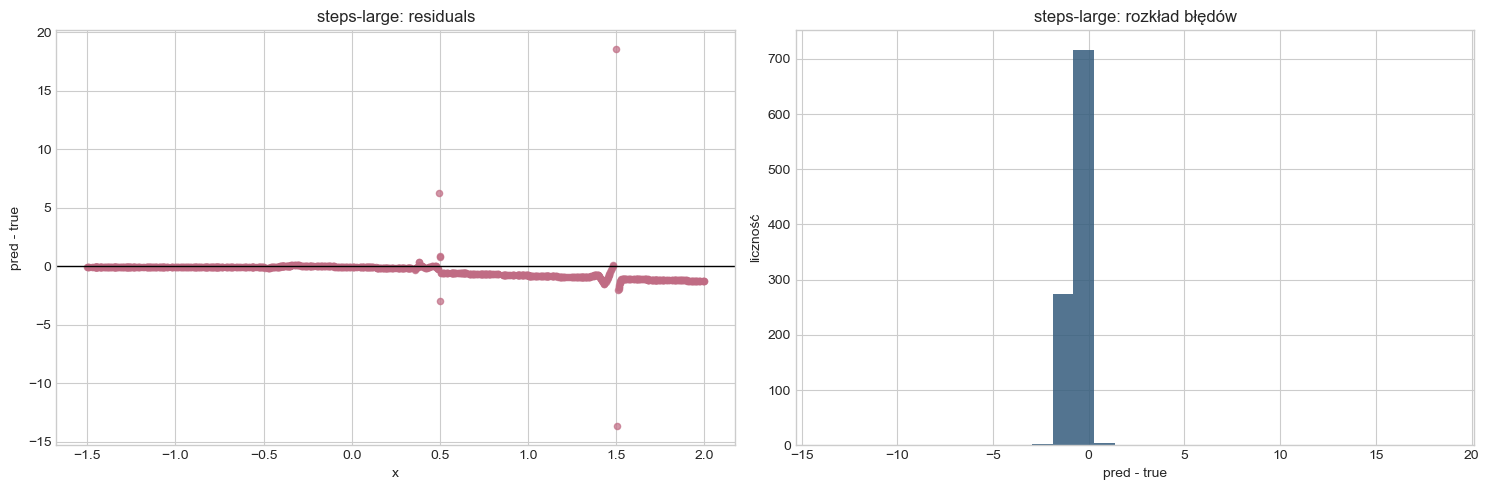

In [7]:
plot_regression_rankings(steps_table, 'steps-large')
plot_regression_learning(steps_results, 'steps-large', top_n=len(steps_results))

for run in steps_results:
    plot_regression_fit(run, 'steps-large')
    plot_regression_residuals(run, 'steps-large')

## 3a. komentarz
Na steps-large lepszy byl wariant 64-32-16 + ReLU: MSE = 0.983.

Wariant 64-32-16 + sigmoid tez dzialal poprawnie, ale byl slabszy: MSE = 3.181.

Wniosek: kandydaci z multimodal-large przenosza sie sensownie na podobne zadanie regresyjne, ale aktywacja nadal mocno wplywa na wynik.

## 4. rings3-regular

In [8]:
rings3_candidates = finalists_to_configs(multimodal_finalists, task='classification')
rings3_results = run_experiments('rings3-regular', 'classification', rings3_candidates)
rings3_table = results_frame(rings3_results)
display(rings3_table)

,dataset,task,hidden_dims,hidden_label,depth,activation,optimizer,lr,epochs,batch_size,params,seconds,best_epoch,best_f1,best_loss
0,rings3-regular,classification,"(64, 32, 16)",64-32-16,3,sigmoid,rmsprop,0.0015,2400,64,2851,28.292668,1400,0.973251,0.078473
1,rings3-regular,classification,"(64, 32, 16)",64-32-16,3,relu,rmsprop,0.0018,2400,64,2851,22.864288,1040,0.970176,0.095656


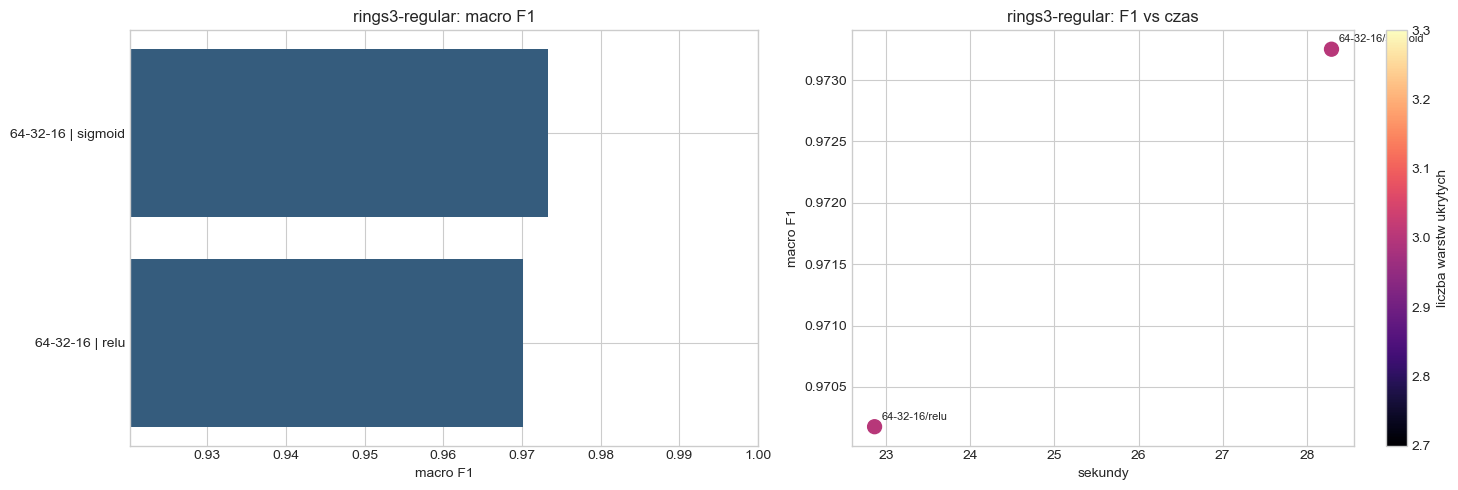

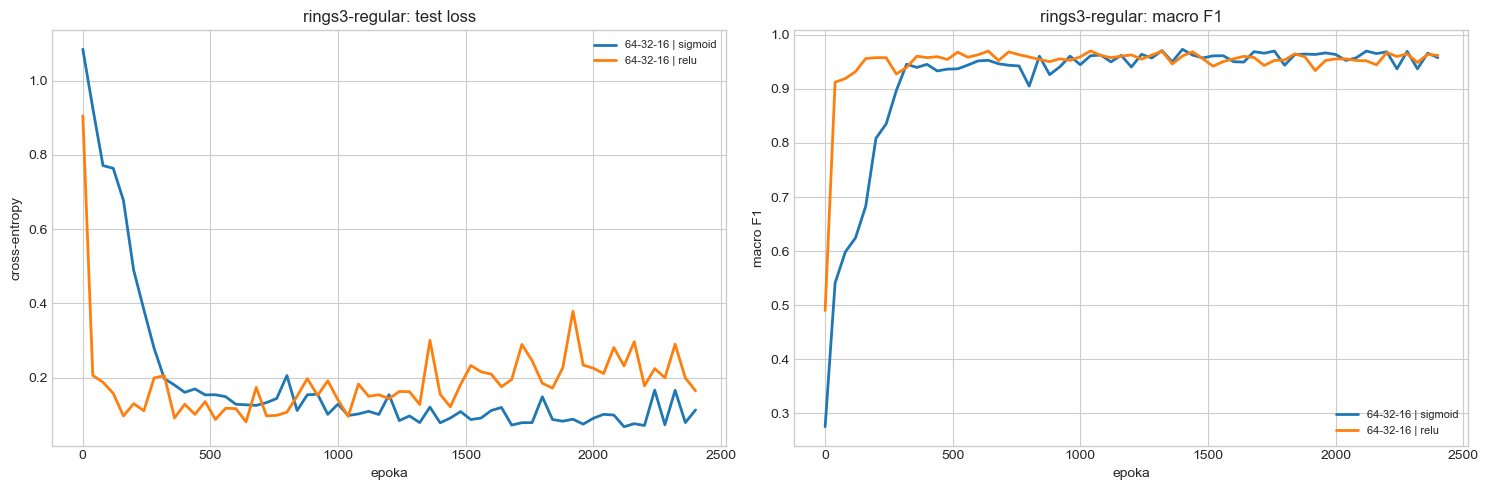

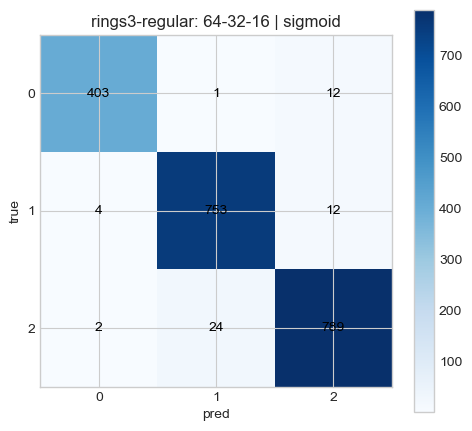

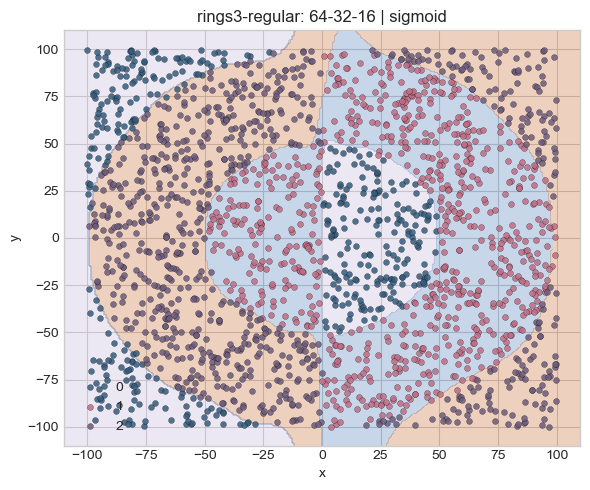

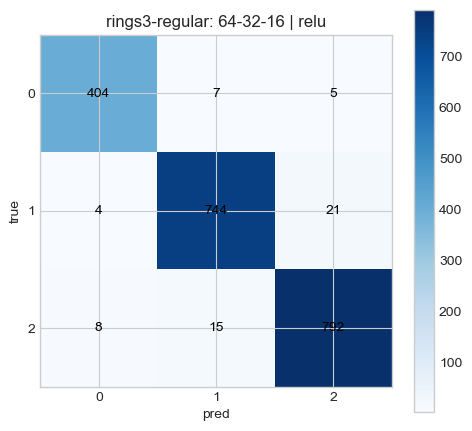

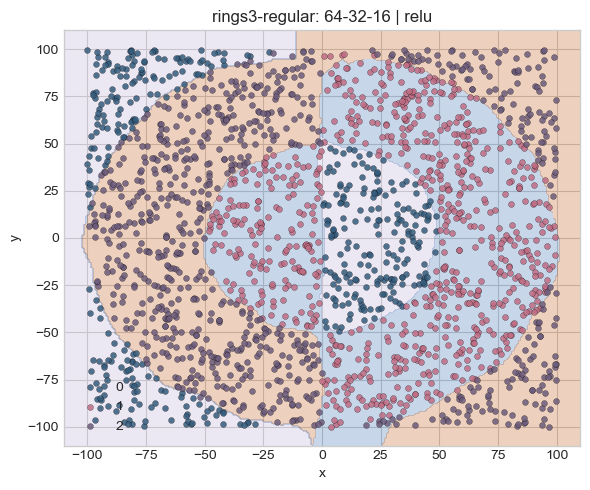

In [9]:
plot_classification_rankings(rings3_table, 'rings3-regular')
plot_classification_learning(rings3_results, 'rings3-regular')

for run in rings3_results:
    plot_confusion(run)
    plot_decision_map(run)

## 4a. komentarz
Na rings3-regular oba modele byly bardzo dobre.

Minimalnie lepszy byl 64-32-16 + sigmoid: macro F1 = 0.973.

ReLU osiagnal 0.970, wiec roznica jest mala i obie aktywacje mozna uznac za skuteczne.

## 5. rings5-regular

In [10]:
rings5_candidates = finalists_to_configs(multimodal_finalists, task='classification')
rings5_results = run_experiments('rings5-regular', 'classification', rings5_candidates)
rings5_table = results_frame(rings5_results)
display(rings5_table)

,dataset,task,hidden_dims,hidden_label,depth,activation,optimizer,lr,epochs,batch_size,params,seconds,best_epoch,best_f1,best_loss
0,rings5-regular,classification,"(64, 32, 16)",64-32-16,3,relu,rmsprop,0.0018,2400,64,2885,30.718401,1560,0.961569,0.175126
1,rings5-regular,classification,"(64, 32, 16)",64-32-16,3,sigmoid,rmsprop,0.0015,2400,64,2885,23.038884,2200,0.955193,0.111486


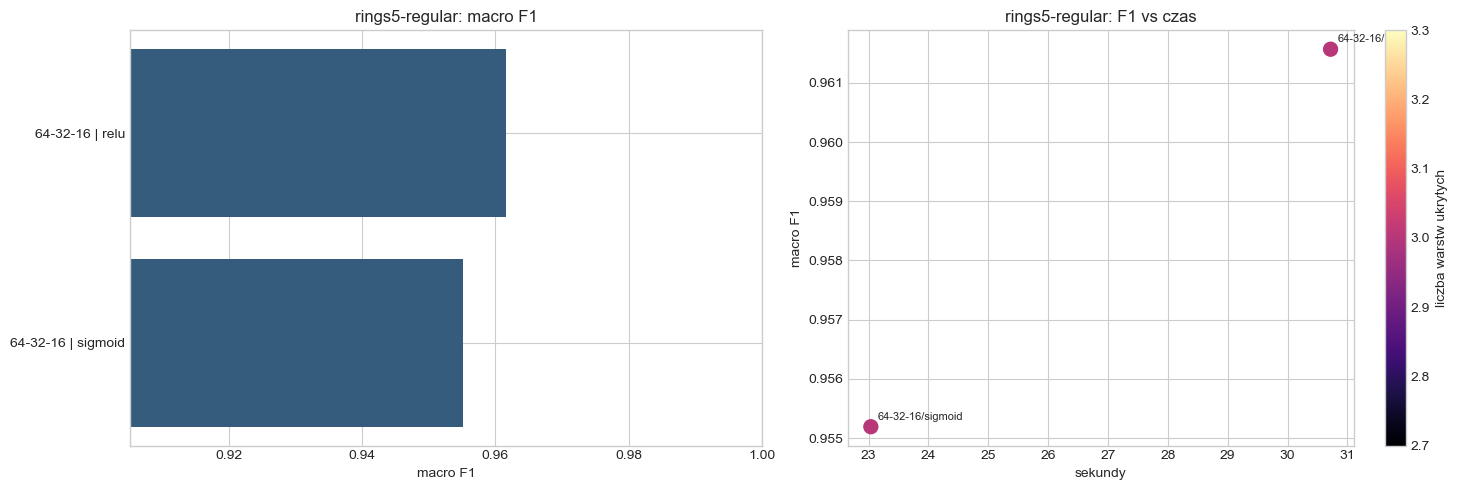

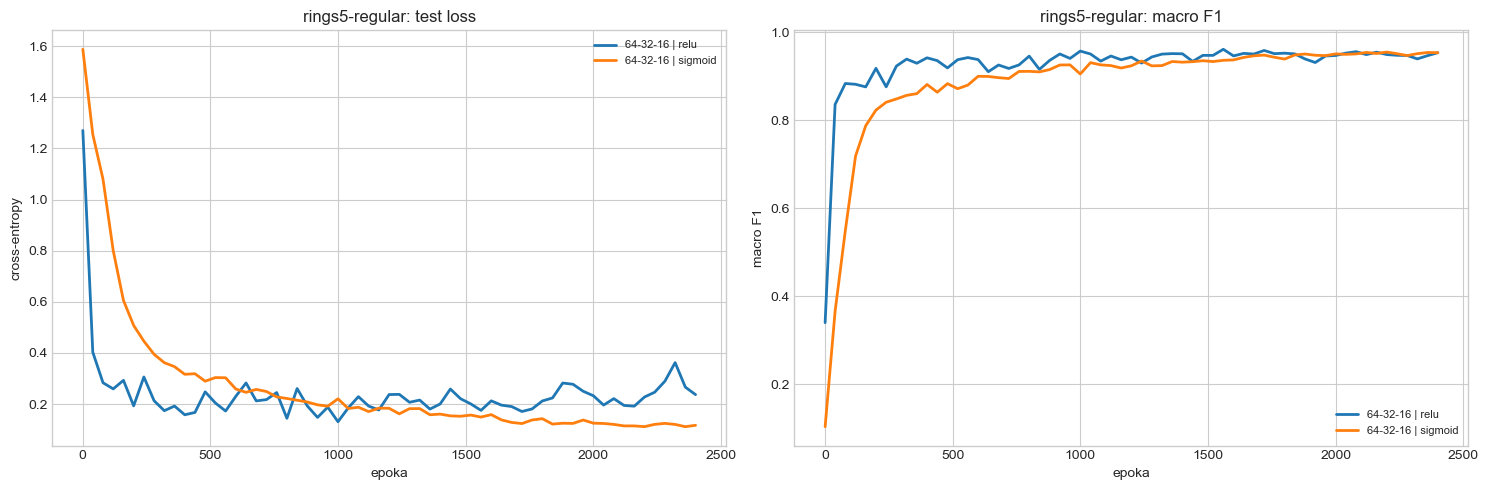

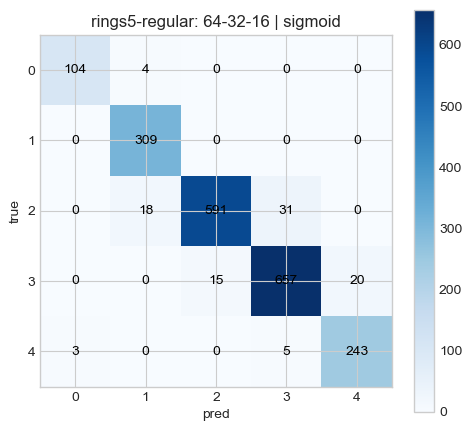

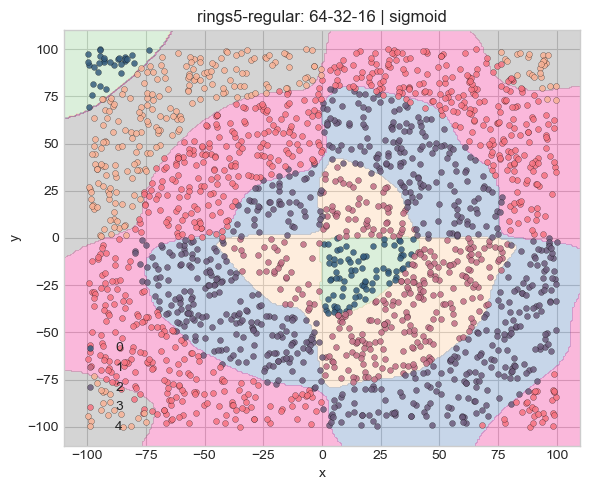

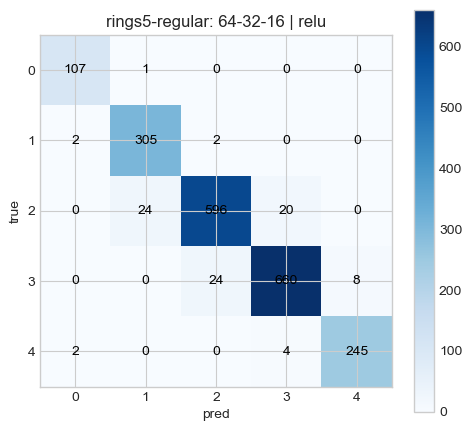

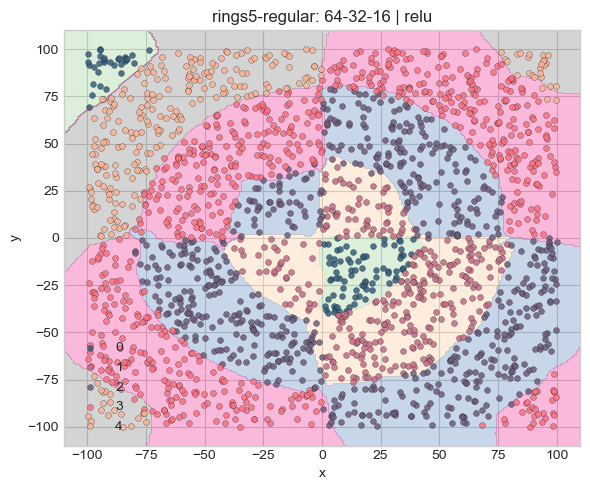

In [11]:
plot_classification_rankings(rings5_table, 'rings5-regular')
plot_classification_learning(rings5_results, 'rings5-regular')

for run in rings5_results:
    plot_confusion(run)
    plot_decision_map(run)

## 5a. komentarz
Na rings5-regular lepszy byl 64-32-16 + ReLU: macro F1 = 0.962.

Sigmoid tez dzialal dobrze, ale slabiej: macro F1 = 0.955.

Przy trudniejszym podziale klas ReLU lepiej odwzorowal granice decyzyjne.

## 5b. wniosek
Najlepiej wypadaly architektury glebsze, szczegolnie 64-32-16.

Linear w warstwach ukrytych okazal sie zbyt slaby.

W regresji najmocniejszy koncowo byl ReLU na steps-large, a w klasyfikacji oba finalowe modele byly skuteczne, z lekka przewaga sigmoid na rings3 i ReLU na rings5.